In [2]:
import pandas as pd

In [3]:
import os

In [4]:
path = r'D:\data analyst vs code\dataset\archive'

In [5]:
pd_orders = pd.read_csv(os.path.join(path, 'olist_orders_dataset.csv'))
pd_items = pd.read_csv(os.path.join(path, 'olist_order_items_dataset.csv'))
pd_products = pd.read_csv(os.path.join(path, 'olist_products_dataset.csv'))
pd_customers = pd.read_csv(os.path.join(path, 'olist_customers_dataset.csv'))
pd_category = pd.read_csv(os.path.join(path, 'product_category_name_translation.csv'))

In [6]:
df_master = pd.merge(pd_orders, pd_items, on='order_id', how='inner')
df_master = pd.merge(df_master, pd_customers, on='customer_id', how='inner')
df_master = pd.merge(df_master, pd_products, on='product_id', how='inner')
df_master = pd.merge(df_master, pd_category, on='product_category_name', how='left')

print(df_master.columns)
display(df_master.head())

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english'],
      dtype='str')


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,BA,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,GO,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,RN,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,SP,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


In [7]:
print(df_master.isnull().sum())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name            1603
product_name_lenght              1603
product_description_lenght       1603
product_photos_qty               1603
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
product_cate

In [8]:
df_master['product_category_name_english'] = df_master['product_category_name_english'].fillna('others')
date_columns = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_columns :
    df_master[col] = pd.to_datetime(df_master[col])
df_master['delivery_days'] = (df_master['order_delivered_customer_date'] - df_master['order_purchase_timestamp']).dt.days
df_master['order_month_year'] = df_master['order_purchase_timestamp'].dt.to_period('M')

display(df_master[['product_category_name_english', 'delivery_days', 'order_month_year']].head())

,product_category_name_english,delivery_days,order_month_year
0,housewares,8.0,2017-10
1,perfumery,13.0,2018-07
2,auto,9.0,2018-08
3,pet_shop,13.0,2017-11
4,stationery,2.0,2018-02


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

C:\Users\User\AppData\Local\Temp\ipykernel_28232\1643955126.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_revenue.values, y=top_revenue.index, palette='viridis')


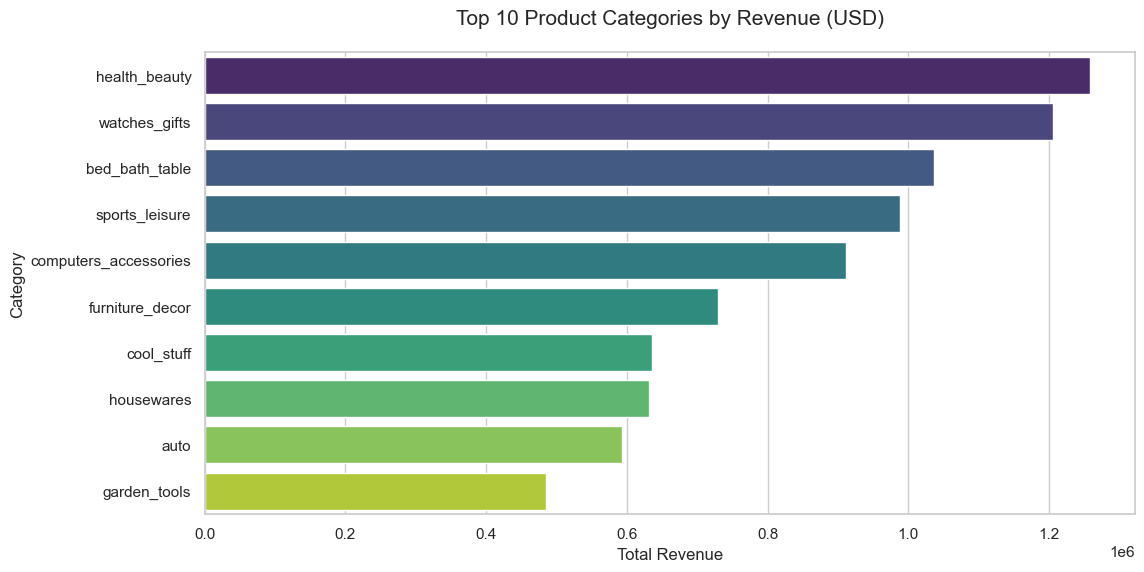

In [11]:
top_revenue = df_master.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)

plt.Figure(figsize=(12, 6))
sns.barplot(x=top_revenue.values, y=top_revenue.index, palette='viridis')
plt.title('Top 10 Product Categories by Revenue (USD)', fontsize=15, pad=20)
plt.xlabel('Total Revenue')
plt.ylabel('Category')
plt.show()

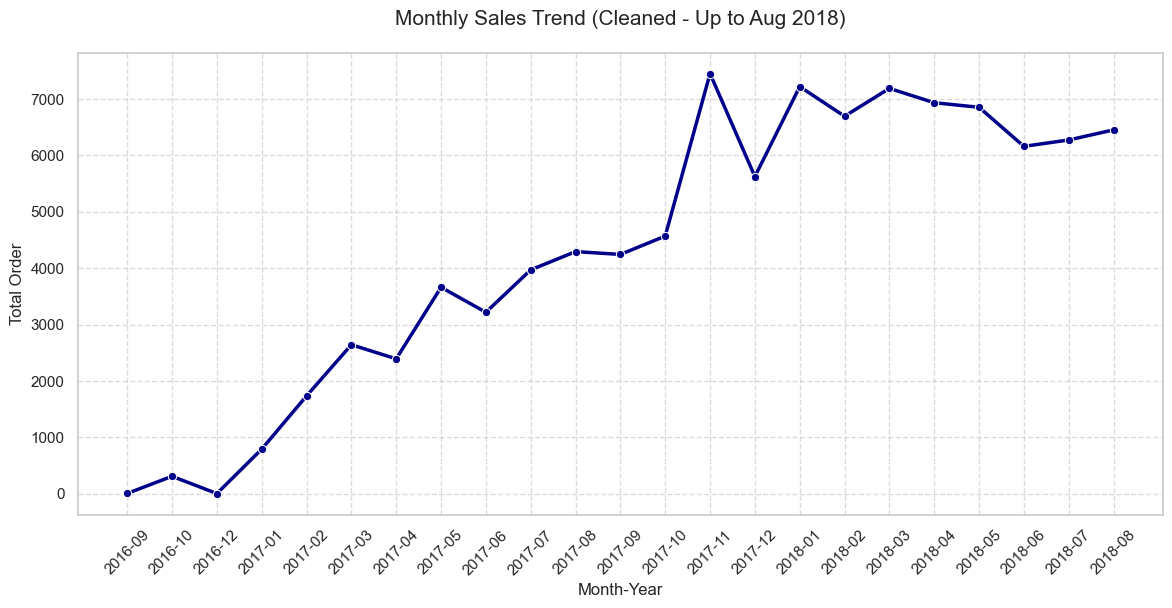

In [17]:
monthly_orders = df_master.groupby('order_month_year')['order_id'].nunique().reset_index()
monthly_orders = monthly_orders[monthly_orders['order_month_year'] < '2018-09']
monthly_orders['order_month_year'] = monthly_orders['order_month_year'].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_orders, x='order_month_year', y='order_id', marker='o', color='darkblue', linewidth=2.5)
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend (Cleaned - Up to Aug 2018)', fontsize=15, pad=20)
plt.xlabel('Month-Year')
plt.ylabel('Total Order')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [18]:
df_master.to_csv('olist_master_cleaned.csv', index=False)